<a href="https://colab.research.google.com/github/2401020564-debug/CREDIT-PREDICTION/blob/main/Give_Me_Some_Credit_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Data Loading and Initial Cleaning
First, download `cs-training.csv` and `cs-test.csv` from the Kaggle Data page (ensure you have accepted the competition rules at the bottom of the Rules tab). Upload both files directly to the Colab files pane. We will load the data and immediately drop any rows where the target variable is completely missing.


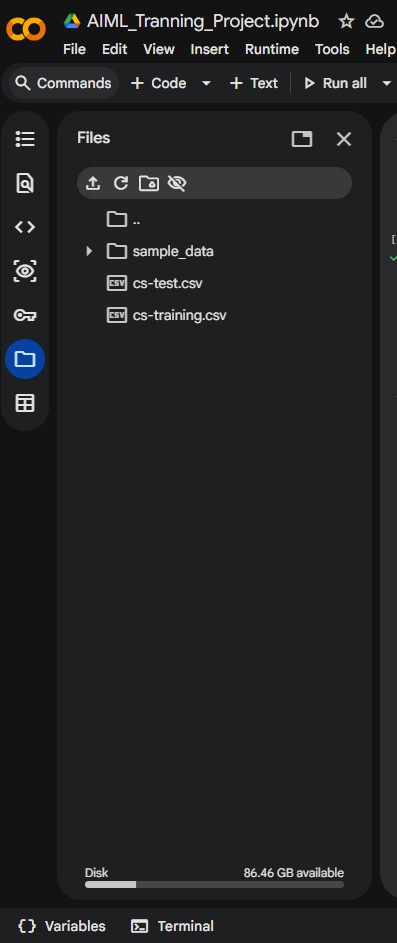

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load the datasets
train = pd.read_csv("/content/cs-training.csv")
test = pd.read_csv("/content/cs-test.csv")

# 2. Clean up the extra index columns
if 'Unnamed: 0' in train.columns:
    train = train.drop('Unnamed: 0', axis=1)
if 'Unnamed: 0' in test.columns:
    test_ids = test['Unnamed: 0'] # Save these IDs for the Kaggle submission
    test = test.drop('Unnamed: 0', axis=1)

# 3. Drop rows where the target variable is missing in the training data
train = train.dropna(subset=['SeriousDlqin2yrs'])

print(f"Cleaned training data shape: {train.shape}")
train = pd.read_csv("/content/cs-training.csv")
test = pd.read_csv("/content/cs-test.csv")

train.drop('Unnamed: 0', axis=1, inplace=True)
test_ids = test['Unnamed: 0']
test.drop('Unnamed: 0', axis=1, inplace=True)

train.head()

Cleaned training data shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Step 2: Exploratory Data Analysis (EDA)
We need to understand the distribution of our target variable (`SeriousDlqin2yrs`). In credit default prediction, the data is usually highly imbalanced (most people pay their loans, very few default).

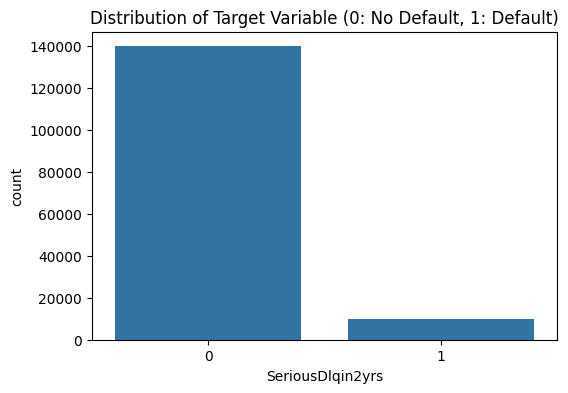


Missing values in the dataset:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [64]:
plt.figure(figsize=(6, 4))
sns.countplot(x='SeriousDlqin2yrs', data=train)
plt.title('Distribution of Target Variable (0: No Default, 1: Default)')
plt.show()

print("\nMissing values in the dataset:")
print(train.isnull().sum()[train.isnull().sum() > 0])

## Step 3: Data Preprocessing
We identified missing values in `MonthlyIncome` and `NumberOfDependents`. We will separate our features and target, handle the missing data using median imputation, and split our data for training and validation.

In [65]:
# 1. Separate features (X) and target (y)
X = train.drop('SeriousDlqin2yrs', axis=1)
y = train['SeriousDlqin2yrs']

# 2. Prepare the test set features (X_test)
if 'SeriousDlqin2yrs' in test.columns:
    X_test = test.drop('SeriousDlqin2yrs', axis=1)
else:
    X_test = test.copy()

# 3. Impute missing values
missing_cols = ['MonthlyIncome', 'NumberOfDependents']
imputer = SimpleImputer(strategy='median')

X[missing_cols] = imputer.fit_transform(X[missing_cols])
X_test[missing_cols] = imputer.transform(X_test[missing_cols])

# 4. Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data preprocessing complete. Ready for modeling.")

Data preprocessing complete. Ready for modeling.


## Step 4: Model Building (XGBoost)
We utilize XGBoost, which is highly efficient for tabular data. To address the class imbalance we discovered during EDA, we use the `scale_pos_weight` parameter to penalize the model more heavily when it misclassifies a true defaulter.

In [66]:
# Initialize the model WITHOUT scale_pos_weight
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

# Train the new, strict model
model.fit(X_train, y_train)
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## Step 5: Comprehensive Model Evaluation
Accuracy alone is misleading for imbalanced datasets. We evaluate the model using a full suite of metrics including Precision, Recall, F1-Score, and ROC-AUC to prove the model's true predictive power.

--- Final Evaluation Metrics (Threshold: 0.36) ---
ROC-AUC Score: 0.8686
Accuracy:      0.9351
Precision:     0.5232
Recall:        0.3267
F1-Score:      0.4022



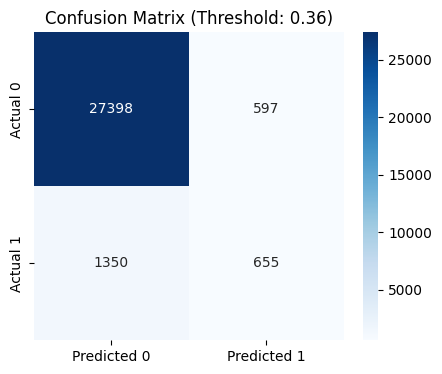

In [78]:
val_probs = model.predict_proba(X_val)[:, 1]
custom_threshold = 0.36
val_preds = (val_probs >= custom_threshold).astype(int)

# Calculate metrics
auc_score = roc_auc_score(y_val, val_probs)
accuracy = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)

print(f"--- Final Evaluation Metrics (Threshold: {custom_threshold}) ---")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.show()

## Step 6: Generate Kaggle Submission
Finally, we apply our trained model to the unseen test data and format the predictions to match Kaggle's submission requirements.

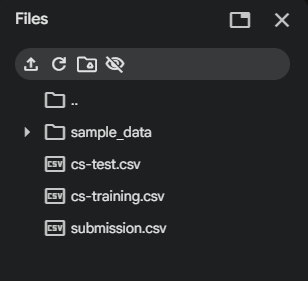

In [68]:
# Predict probabilities on the official test data
test_preds = model.predict_proba(X_test)[:, 1]

# Submission Dataframe
submission = pd.DataFrame({
    'Id': test_ids,
    'Probability': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission successfully saved to submission.csv! Ready for download.")

Submission successfully saved to submission.csv! Ready for download.


## UI Interface

In [69]:
model.save_model('credit_model.json')

print("Model successfully saved as JSON!")

Model successfully saved as JSON!
